# Mac and Linux setup

Make sure to have enabled the environment set up for running `dimelo` analysis. See the readme for details. If you are running your jupyter notebook some way other than by the `jupyter notebook` command in the command line from within your activated `conda` environment, you may need to use `ipykernel` to connect this notebook appropriately to the environment with `dimelo` and `modkit` installed.

# Colab setup

If you are running in Google Colab, run the cells below. **It is expected that Colab will make you restart your runtime to enable new package versions.** 

In [1]:
# Lets Colab access your Google drive
try:
    from google.colab import drive
except:
    print("""
You don't seem to be running on Google Colab so this cell is not going to be useful for you.
Make sure you are running you notebook in a conda environment set up as per README.md.
Once you have this notebook running in a correctly configured environment, proceed to the rest of the cells.
          """)
else:
    drive.mount('/content/drive')
    # Install condacolab to let us get the modkit dependency
    !pip install -q condacolab
    import condacolab
    condacolab.install()
    # Install modkit
    !conda install nanoporetech::modkit==0.2.4
    # Clone the repo, change the active path to be inside the repo, and install the package
    !rm -r dimelo
    !git clone https://github.com/streetslab/dimelo
    import os
    os.chdir('dimelo')
    !pip install ipywidgets==7.7.1 .



You don't seem to be running on Google Colab so this cell is not going to be useful for you.
Make sure you are running you notebook in a conda environment set up as per README.md.
Once you have this notebook running in a correctly configured environment, proceed to the rest of the cells.
          


After runtime restart in previous cell, run this cell to make sure your notebook is set up.

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    import os
    os.chdir('dimelo')   
except:
    pass

# System and Versions Information

## Conda Environment

Run this cell to list the packages present in your conda environment

In [3]:
!conda activate dimelo-toolkit


CondaError: Run 'conda init' before 'conda activate'



## System Information

Run this cell to list system information about your machine

In [4]:
import platform
print('System:',platform.system())
print('Release:',platform.release())
print('Version:',platform.version())
print('Processor:',platform.processor())

System: Darwin
Release: 25.5.0
Version: Darwin Kernel Version 25.5.0: Fri Mar 20 18:56:10 PDT 2026; root:xnu-12377.120.72.0.4~13/RELEASE_ARM64_T6020
Processor: arm


## Git Repo Version

Run this cell to capture the exact repo version you're running, in case we need to debug anything

In [5]:
!git -C . log -1 --format=%H

87186168c2ac4f8c12f91385e2ca42688ac6c5c7


## Modkit Version Selection (Demo)

Use this cell to pin a preferred `modkit` version for reproducible runs.
It detects your installed version and records a `MODKIT_VERSION_SELECTED` value for downstream cells.


In [6]:
import re
import shutil
import subprocess

# Target modkit version for this notebook run.
# Auto-install is enabled so Run All upgrades PATH to this version when needed.
MODKIT_VERSION_SELECTED = "0.6.1"
AUTO_INSTALL_SELECTED_MODKIT = True


def _installed_modkit_version(binary: str = "modkit") -> str | None:
    try:
        proc = subprocess.run([binary, "--version"], capture_output=True, text=True, check=True)
    except Exception:
        return None
    text = (proc.stdout or proc.stderr or "").strip()
    m = re.search(r"(\d+\.\d+\.\d+)", text)
    return m.group(1) if m else text


def ensure_selected_modkit(
    selected: str = MODKIT_VERSION_SELECTED,
    binary: str = "modkit",
    auto_install: bool = AUTO_INSTALL_SELECTED_MODKIT,
) -> str:
    installed = _installed_modkit_version(binary)
    if installed != selected and auto_install:
        installer = shutil.which("mamba") or shutil.which("conda")
        if installer is None:
            raise RuntimeError(
                "modkit version mismatch and no conda/mamba installer found on PATH. "
                "Install modkit manually or set a matching environment."
            )
        subprocess.run(
            [installer, "install", "-y", f"nanoporetech::modkit=={selected}"],
            check=True,
        )
        installed = _installed_modkit_version(binary)


    # Clear cached capability detection so command flags match the active binary version.
    try:
        from dimelo import run_modkit
        run_modkit._get_modkit_capabilities_cached.cache_clear()
    except Exception:
        pass

    if installed != selected:
        raise RuntimeError(
            f"Notebook requires modkit {selected}, but PATH resolves to {installed!r}. "
            "Activate the intended environment or enable AUTO_INSTALL_SELECTED_MODKIT."
        )

    print(f"modkit selected: {selected}")
    print(f"modkit active  : {installed}")
    return binary


MODKIT_BINARY = ensure_selected_modkit()


def run_modkit_checked(args: list[str]) -> None:
    ensure_selected_modkit(binary=MODKIT_BINARY)
    cmd = [MODKIT_BINARY, *[str(a) for a in args]]
    print("$", " ".join(cmd))
    subprocess.run(cmd, check=True)


modkit selected: 0.6.1
modkit active  : 0.6.1


## Modkit Version Comparison (Cached Results)

This cell summarizes the cached benchmark at `modkit_test_results.json` and compares runtime/output behavior across tested versions.


,version,runtime_mean_s,runtime_std_s,runtime_min_s,runtime_max_s
0,0.6.1,2.081953,0.276318,1.766293,2.280039
1,0.2.4,5.246848,0.370882,5.006230,5.673964


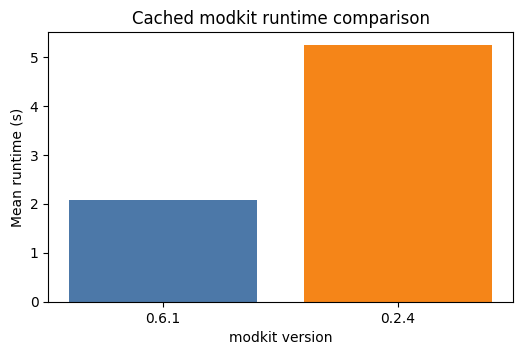

Compatibility flags


,version,supports_force_allow_implicit,supports_modified_bases,supports_reference_long_opt,supports_reference_short_opt
0,0.2.4,True,False,False,True
1,0.6.1,False,True,True,True


Pileup comparison summary


,row_delta,row_delta_pct_vs_024,outputs_identical_sha256
0,1603,0.312757,False


Recommendations
- Prefer modkit 0.6.1 for pileup runtime in this workflow (~60.3% faster on average).
- Backend-aware command building is required: use --force-allow-implicit for 0.2.4 only.

Re-checking selected modkit binary after comparison...
modkit selected: 0.6.1
modkit active  : 0.6.1


In [7]:
import json
from pathlib import Path

import pandas as pd
from matplotlib import pyplot as plt

results_path = Path("modkit_test_results.json")
if not results_path.exists():
    print(f"No benchmark file found at {results_path}.")
else:
    results = json.loads(results_path.read_text())

    runtime_summary = pd.DataFrame(results.get("runtime_summary", []))
    if not runtime_summary.empty:
        runtime_summary = runtime_summary.sort_values("runtime_mean_s").reset_index(drop=True)
        display(runtime_summary)

        fig, ax = plt.subplots(figsize=(6, 3.5))
        ax.bar(runtime_summary["version"], runtime_summary["runtime_mean_s"], color=["#4C78A8", "#F58518", "#54A24B"])
        ax.set_ylabel("Mean runtime (s)")
        ax.set_xlabel("modkit version")
        ax.set_title("Cached modkit runtime comparison")
        plt.show()

    edge_flags = pd.DataFrame(results.get("edge_case_flags", []))
    if not edge_flags.empty:
        print("Compatibility flags")
        display(edge_flags)

    pileup_cmp = results.get("pileup_comparison", {})
    if pileup_cmp:
        print("Pileup comparison summary")
        display(pd.DataFrame([pileup_cmp]))

    print("Recommendations")
    for rec in results.get("recommendations", []):
        print(f"- {rec}")

print("\nRe-checking selected modkit binary after comparison...")
MODKIT_BINARY = ensure_selected_modkit(binary=MODKIT_BINARY)


# Initialization

In [8]:
from pathlib import Path
from matplotlib import pyplot as plt    
import urllib, gzip

In [9]:
# Ensure this notebook imports the local repo version of dimelo
import importlib
from pathlib import Path
import dimelo

importlib.reload(dimelo)
print('dimelo module path:', Path(dimelo.__file__).resolve())
print('dimelo version:', getattr(dimelo, '__version__', 'unknown'))


dimelo module path: /Users/ngamarra/Documents/GitHub/dimelo-toolkit/dimelo/__init__.py
dimelo version: unknown


In [10]:
# Base input and output directories
test_data_dir = Path('./dimelo/test/data')
output_dir = Path('./dimelo/test/output')

output_dir.mkdir(exist_ok=True)

# Input files
ctcf_bam_file = test_data_dir / 'ctcf_demo.sorted.bam'
ctcf_guppy_bam_file = test_data_dir / 'winnowmap_guppy_merge_subset.updated.bam'
ctcf_target_regions = test_data_dir / 'ctcf_demo_peak.bed'
ctcf_off_target_regions = test_data_dir / 'ctcf_demo_not_peak.bed'

The cell below only needs to run once; if you try to run it with the reference genome already downloaded it will likely just not complete.

In [11]:
ref_genome_url = 'https://s3-us-west-2.amazonaws.com/human-pangenomics/T2T/CHM13/assemblies/chm13.draft_v1.0.fasta.gz'
ref_genome_gz = output_dir / 'chm13.draft_v1.0.fasta.gz'
ref_genome_file = output_dir / 'chm13.draft_v1.0.fasta'
force_redownload = False
if ref_genome_file.exists() and not force_redownload:
    print('Reference genome already present. Set force_redownload=True to if you want to download it again.')
else:
    urllib.request.urlretrieve(ref_genome_url,ref_genome_gz)

    with gzip.open(ref_genome_gz,'rb') as gzip_file:
        with open(ref_genome_file,'wb') as output_file:
            for chunk in gzip_file:
                output_file.write(chunk)

    ref_genome_gz.unlink()
    print("Reference genome downloaded and decompressed.")
# !curl https://s3-us-west-2.amazonaws.com/human-pangenomics/T2T/CHM13/assemblies/chm13.draft_v1.0.fasta.gz -o ./test/output/chm13.draft_v1.0.fasta.gz
# !gunzip ./test/output/chm13.draft_v1.0.fasta.gz

Reference genome already present. Set force_redownload=True to if you want to download it again.


# Basic Use Overview

For details on parameters and functionality breakdown, please read the README sections on **Basic Use**, especially **Parameters and what they mean**.

# Parsing

In [ ]:
import importlib
from dimelo import parse_bam, run_modkit

# Ensure notebook uses latest local backend code and capability logic.
importlib.reload(run_modkit)
importlib.reload(parse_bam)

# Reset cached capability detection after reloads/version changes.
run_modkit._get_modkit_capabilities_cached.cache_clear()


## Pileup and Update Tags

Attempting to parse a malformed BAM file will raise an error, thanks to input BAM format checking. Passing a bam file that doesn't meet the specifications directly to `modkit` will typically result in an empty ouput file; `modkit` will find no valid base modifications and return all-zero data.

Megalodon and Guppy bam files are considered malformed because they do not meet the latest .bam spec. Some newer basecallers output correctly formatted files without requiring additional processing.

However, `modkit` comes with two tools that can update bam files to meet spec.

In [ ]:
try:
    pileup_file, pileup_regions = parse_bam.pileup(
        input_file=ctcf_bam_file,
        output_name='ctcf_demo_pileup_on_target',
        ref_genome=ref_genome_file,
        output_directory=output_dir,
        regions=[ctcf_target_regions,ctcf_off_target_regions],
        motifs=['A,0','CG,0'],
        # parsing can optionally specify mod codes. 
        # The default is Y or a for adenine and m or Z for cytosine, corresponding to methylation
        # motifs = ['A,0,Y','CG,0,Z'], 
        thresh=190,
        window_size=1000,
        # cores = 1, # uncomment this line if your process appears to be terminating early (reduces memory usage)
        # quiet = True,
        # cleanup = False,
        # log=True,
        modkit_executable=MODKIT_BINARY,
    )
    print('The code executed successfully.')
except Exception as e:
    print('This is expected to fail. Read the error message below:\n\n')
    print(e)


To fix this, follow the suggestion from the error and run `modkit update-tags`...

In [14]:
run_modkit_checked([
    "update-tags",
    "dimelo/test/data/ctcf_demo.sorted.bam",
    "dimelo/test/output/ctcf_demo.updated.bam",
    "--mode",
    "ambiguous",
])


modkit selected: 0.6.1
modkit active  : 0.6.1
$ modkit update-tags dimelo/test/data/ctcf_demo.sorted.bam dimelo/test/output/ctcf_demo.updated.bam --mode ambiguous


> done, 1024 records processed


In [15]:
ctcf_bam_file_updated = output_dir / 'ctcf_demo.updated.bam'

...and reindex the resulting file.

In [16]:
import pysam

pysam.index(str(ctcf_bam_file_updated))

''

Finally, the updated .bam file can be parsed, both for pileup and read extraction:

In [ ]:
pileup_file, pileup_regions = parse_bam.pileup(
    input_file=ctcf_bam_file_updated,
    output_name='ctcf_demo_pileup_on_target',
    ref_genome=ref_genome_file,
    output_directory=output_dir,
    regions=[ctcf_target_regions,ctcf_off_target_regions],
    motifs=['A,0','CG,0'],
    # parsing can optionally specify mod codes. 
    # The default is Y or a for adenine and m or Z for cytosine, corresponding to methylation
    # motifs = ['A,0,Y','CG,0,Z'], 
    thresh=190,
    window_size=1000,
    # cores = 1, # uncomment this line if your process appears to be terminating early (reduces memory usage)
    # quiet = True,
    # cleanup = False,
    # log=True,
    modkit_executable=MODKIT_BINARY,
)


## Extract

In [ ]:
extract_file, extract_regions = parse_bam.extract(
    input_file=ctcf_bam_file_updated,
    output_name='ctcf_demo_extract',
    ref_genome=ref_genome_file,
    output_directory=output_dir,
    regions=[ctcf_target_regions,ctcf_off_target_regions],
    motifs=['A,0','CG,0'],
    # parsing can optionally specify mod codes. 
    # The default is Y or a for adenine and m or Z for cytosine, corresponding to methylation
    # motifs = ['A,0,Y','CG,0,Z'], 
    thresh=190,
    window_size=2000,
    # cores = 1, # uncomment this line if your process appears to be terminating early (reduces memory usage)
    # quiet = True,
    # cleanup = False,
    # log=True,
    modkit_executable=MODKIT_BINARY,
)


# Plotting

## Plot Enrichment Profile

In [ ]:
from dimelo import plot_enrichment_profile

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

<Axes: xlabel='pos', ylabel='fraction modified bases'>

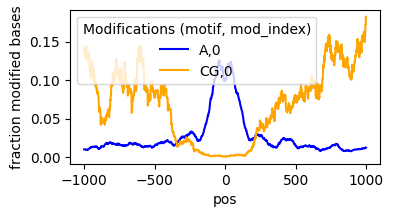

In [ ]:
plt.figure(figsize=(4, 2)) # If you want a different sized plot, you can us matplotlib commands
plot_enrichment_profile.by_modification(
    mod_file_name=pileup_file,
    regions=ctcf_target_regions,
    window_size=1000,
    motifs=['A,0','CG,0'],
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    regions_5to3prime=False, # if set to True, regions on the reverse (-) strand will be flipped so everything is 5 prime to 3 prime
    smooth_window=50,
    palette = { # you can pass down kwargs to sns barplot if you want to
        'A,0':'blue',
        'CG,0':'orange'
    }
)

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

Loading data:   0%|          | 0/100 [00:00<?, ?it/s]

Text(0, 0.5, 'mA/A')

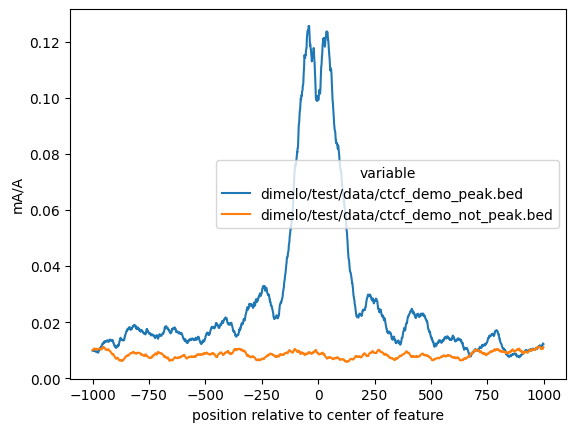

In [ ]:
plot_enrichment_profile.by_regions(
    mod_file_name=pileup_file,
    regions_list=[ctcf_target_regions,ctcf_off_target_regions],
    window_size=1000,
    motif='A,0',
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    regions_5to3prime=False, # if set to True, regions on the reverse (-) strand will be flipped so everything is 5 prime to 3 prime
    smooth_window=50,
)
plt.xlabel('position relative to center of feature')
plt.ylabel('mA/A') # You can also use matplotlib commands to rename axes and more

## Plot Enrichment

In [ ]:
from dimelo import plot_enrichment

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

Loading data:   0%|          | 0/100 [00:00<?, ?it/s]

<Axes: ylabel='fraction modified bases'>

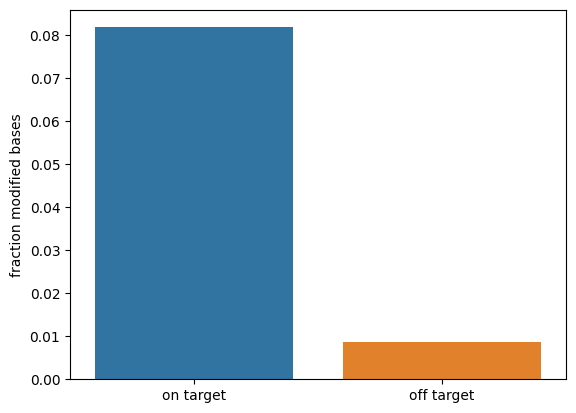

In [ ]:
plot_enrichment.by_regions(
    mod_file_name=pileup_file,
    regions_list=[ctcf_target_regions, ctcf_off_target_regions],
    motif='A,0',
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    sample_names=['on target', 'off target'],
    )

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

Text(0.5, 1.0, 'dimelo/test/data/ctcf_demo_peak.bed')

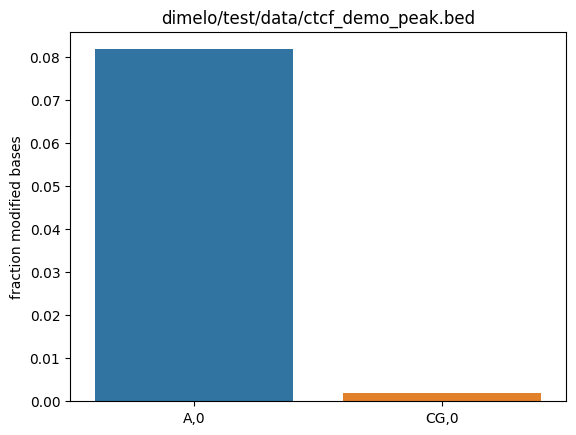

In [ ]:
plot_enrichment.by_modification(
    mod_file_name=pileup_file,
    regions=ctcf_target_regions,
    motifs=['A,0','CG,0'],
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    )
plt.title(ctcf_target_regions)

Loading data:   0%|          | 0/100 [00:00<?, ?it/s]

Loading data:   0%|          | 0/100 [00:00<?, ?it/s]

Text(0.5, 1.0, 'dimelo/test/data/ctcf_demo_not_peak.bed')

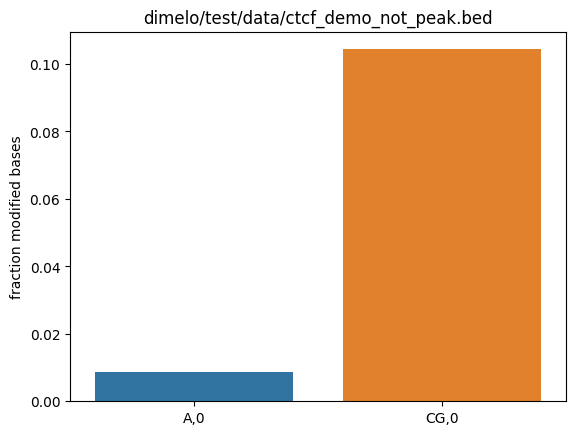

In [ ]:
plot_enrichment.by_modification(
    mod_file_name=pileup_file,
    regions=ctcf_off_target_regions,
    motifs=['A,0','CG,0'],
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    )
plt.title(ctcf_off_target_regions)

## Plot Reads

In [ ]:
from dimelo import plot_reads

Text(0.5, 1.0, "CTCF target data, 100 known binding locations\nsort_by=['shuffle'] i.e. default")

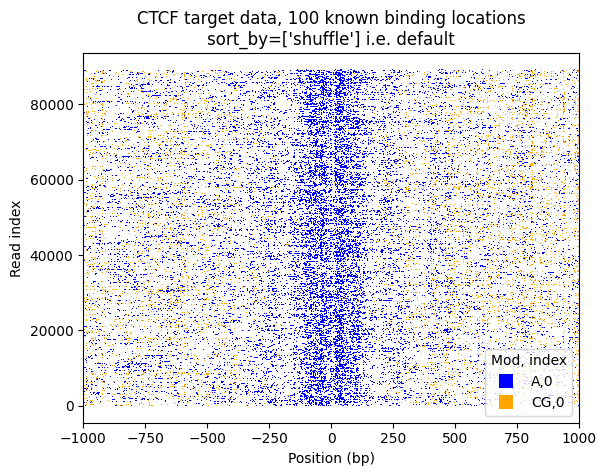

In [ ]:
plot_reads.plot_reads(
    mod_file_name=extract_file,
    regions=ctcf_target_regions,
    motifs=['A,0', 'CG,0'],
    window_size=1000,
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    regions_5to3prime=False, # if set to True, regions on the reverse (-) strand will be flipped so everything is 5 prime to 3 prime
)
plt.title("CTCF target data, 100 known binding locations\nsort_by=['shuffle'] i.e. default")

## Plot Browser

The read browser plot lets you see modification locations and probabilities in the same visualization. While the `pileup` operation and downstream plots by definition requires a threshold, but plot browser requires raw probabilities. Read extraction can be run with *either* binary modification calls *or* raw probabilities. Run the cell below to re-extract the single reads but with raw base modification probabilities for plot browser.

In [ ]:
from dimelo import plot_read_browser

In [ ]:
try:
    plot_read_browser.plot_read_browser(
    mod_file_name=extract_file,
    region='chr1:114357437-114359753', # you can only browser a single region, not a bed file or list of regions.
    # The only cap on region size is your computer's memory and your patience
    motifs=['CG,0','A,0'],
    thresh=0.5,
    single_strand=False,
    sort_by="collapse",#you can sort by anything that the loading function accepts, but the special "collapse" option doesn't allow other sorting
    hover=False, #turning off hover will remove the hoverover read names and other info 
    )
except Exception as e:
    print('This is expected to fail. Read the error message below:\n\n')
    print(e)

This is expected to fail. Read the error message below:


A threshold has been applied to this .h5 single read data. plot_read_browser must be used with an .h5 file extracted using thresh=None.


In [ ]:
extract_file_no_thresh, _ = parse_bam.extract(
    input_file=ctcf_bam_file_updated,
    output_name='ctcf_demo_extract_no_thresh',
    ref_genome=ref_genome_file,
    output_directory=output_dir,
    regions=[ctcf_target_regions,ctcf_off_target_regions],
    motifs=['A,0','CG,0'],
    # parsing can optionally specify mod codes. 
    # The default is Y or a for adenine and m or Z for cytosine, corresponding to methylation
    # motifs = ['A,0,Y','CG,0,Z'], 
    # thresh=190,
    window_size=1000,
    # cores = 1, # uncomment this line if your process appears to be terminating early (reduces memory usage)
    # quiet = True,
    # cleanup = False,
    # log=True,
    modkit_executable=MODKIT_BINARY,
)


Resorting to unclean kill browser.


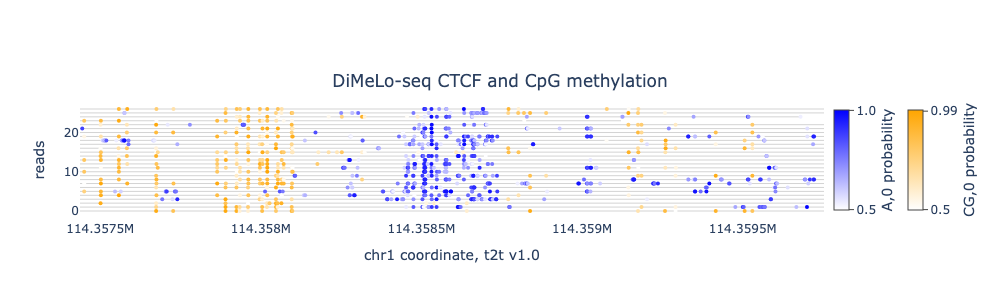

In [ ]:
from IPython.display import Image, display
from plotly.io import to_image
fig = plot_read_browser.plot_read_browser(
    mod_file_name=extract_file_no_thresh,
    region='chr1:114357437-114359753', # you can only browser a single region, not a bed file or list of regions.
    # The only cap on region size is your computer's memory and your patience
    motifs=['CG,0','A,0'],
    thresh=0.5,
    single_strand=False,
    sort_by="collapse",#you can sort by anything that the loading function accepts, but the special "collapse" option doesn't allow other sorting
    hover=False, #turning off hover will remove the hoverover read names and other info
)
# plot browser is made using plotly, so you can use the returned "fig" object to make updates using plotly commands
fig.update_layout(
    width=1000,# these values are in pixels
    height=300,    
    title={
        'text': 'DiMeLo-seq CTCF and CpG methylation',
        'x': 0.5,
        'xanchor': 'center',
        'y': 0.75,  # Adjust the vertical position of the title
        'yanchor': 'top',
        'pad': {'b': 10} 
    },
    xaxis_title='chr1 coordinate, t2t v1.0',
    yaxis_title='reads'
)
# Comment out these lines to display an interactive plot with e.g. zoom and pan
png_bytes = to_image(fig, format="png", width=1000, height=300)
display(Image(png_bytes))

When using the read browser, one can optionally request plotting of a random subset of the reads using the `subset_parameters` argument:

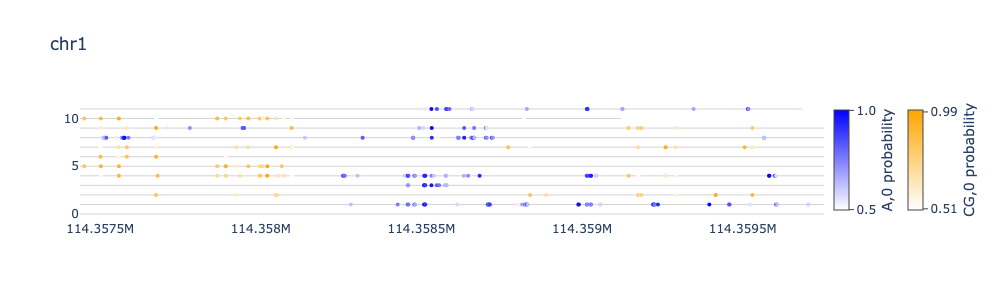

In [ ]:
fig = plot_read_browser.plot_read_browser(
    mod_file_name=extract_file_no_thresh,
    region='chr1:114357437-114359753',
    motifs=['CG,0','A,0'],
    thresh=0.5,
    single_strand=False,
    sort_by="collapse",
    hover=False,
    subset_parameters={"frac": 0.25}
)
# Comment out these lines to display an interactive plot with e.g. zoom and pan
png_bytes = to_image(fig, format="png", width=1000, height=300)
display(Image(png_bytes))

## Plot read depth profile

The depth profile plotters allow you to visualize the depth of your data, both at a single locus and across many loci. This is always showing the read depth that is *usable for DiMeLo-seq*, that is to say read depth for the motifs in question where there is mod tag information available for the putatively modified nucleotide. Because not all motifs are reverse-complement-symmetrical, the depth is expressed on a per strand basis. You can use the same single_strand command as in enrichment plotters to only pull data from the strand specified for a region. Otherwise, data will be pulled from both strands, but the populated read depth will for each position only come from one strand, so you will still only get effectively (full read depth) / 2. 

In [ ]:
from dimelo import plot_depth_profile

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

<Axes: title={'center': 'Reverse strand mod read depth'}, xlabel='Position (bp)', ylabel='per strand reads\nwith motif and mod info'>

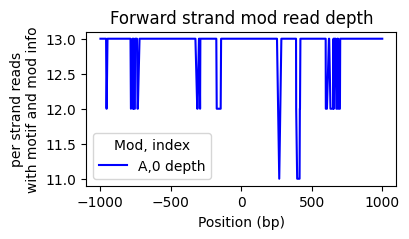

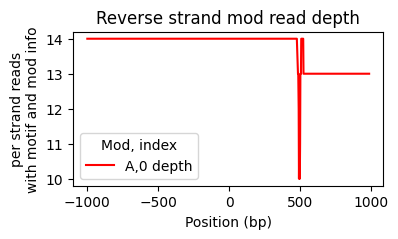

In [ ]:
plt.figure(figsize=(4, 2)) # If you want a different sized plot, you can us matplotlib commands
plt.title("Forward strand mod read depth")
plot_depth_profile.by_modification(
    mod_file_name=pileup_file,
    regions='chr1:114357437-114359753,+',
    window_size=1000,
    motifs=['A,0'],
    single_strand=True, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    regions_5to3prime=False, # if set to True, regions on the reverse (-) strand will be flipped so everything is 5 prime to 3 prime
    smooth_window=None,
    palette = { # you can pass down kwargs to sns barplot if you want to
        'A,0 depth':'blue',
    }
)
plt.figure(figsize=(4, 2)) # If you want a different sized plot, you can us matplotlib commands
plt.title("Reverse strand mod read depth")
plot_depth_profile.by_modification(
    mod_file_name=pileup_file,
    regions='chr1:114357437-114359753,-',
    window_size=1000,
    motifs=['A,0'],
    single_strand=True, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    regions_5to3prime=False, # if set to True, regions on the reverse (-) strand will be flipped so everything is 5 prime to 3 prime
    smooth_window=None,
    palette = { # you can pass down kwargs to sns barplot if you want to
        'A,0 depth':'red',
    }
)

You can superimpose plots of mod fraction enrichment and read depth to get a better picture of what is going on, and how meaningful results are. For example, in the below plot, we see that adenines are somewhat depleted at CTCF sites, while CpG motifs are enriched. The adenine modification signal has much higher read depth because `A,0` motifs are much more prevalent than `CG,0` motifs. With this set of loci and read depth, the CpG signal flanking the CTCF sites is quite low depth - explaining the noisy trace.

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

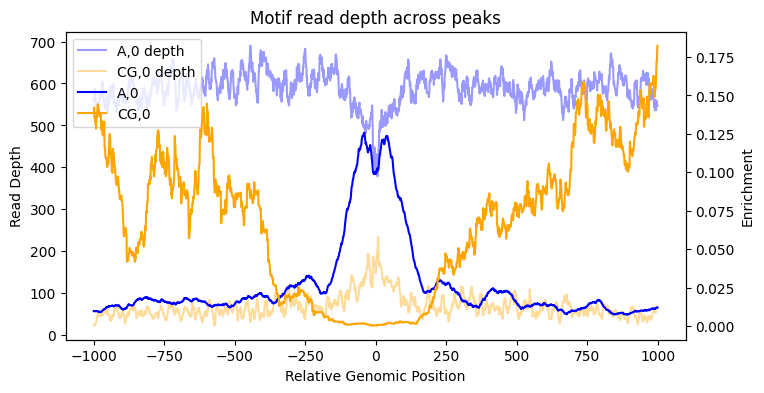

In [ ]:
fig, ax1 = plt.subplots(figsize=(8, 4))  # Create figure and primary axis
ax2 = ax1.twinx()  # Create secondary y-axis sharing the same x-axis
plt.title("Motif read depth across peaks")
plot_depth_profile.by_modification(
    mod_file_name=pileup_file,
    regions=ctcf_target_regions,
    window_size=1000,
    motifs=['A,0','CG,0'],
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    regions_5to3prime=False, # if set to True, regions on the reverse (-) strand will be flipped so everything is 5 prime to 3 prime
    smooth_window=10,
    palette = { # you can pass down kwargs to sns barplot if you want to
        'A,0 depth':'blue',
        'CG,0 depth':'orange',
    },
    alpha=0.4,
    ax=ax1,
)
plot_enrichment_profile.by_modification(
    mod_file_name=pileup_file,
    regions=ctcf_target_regions,
    window_size=1000,
    motifs=['A,0','CG,0'],
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    regions_5to3prime=False, # if set to True, regions on the reverse (-) strand will be flipped so everything is 5 prime to 3 prime
    smooth_window=50,
    palette = { # you can pass down kwargs to sns barplot if you want to
        'A,0':'blue',
        'CG,0':'orange'
    },
    ax=ax2,
)
# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.set_ylabel("Read Depth")
ax2.set_ylabel("Enrichment")
ax1.set_xlabel("Relative Genomic Position")
ax2.get_legend().remove()

### Plot depth histogram

Depth histograms show the distribution of read depths across sites, either averaging each locus into a single value or providing readouts across all genomic coordinates.

In [ ]:
from dimelo import plot_depth_histogram

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

<Axes: xlabel='per strand read\ndepth in region', ylabel='regions count'>

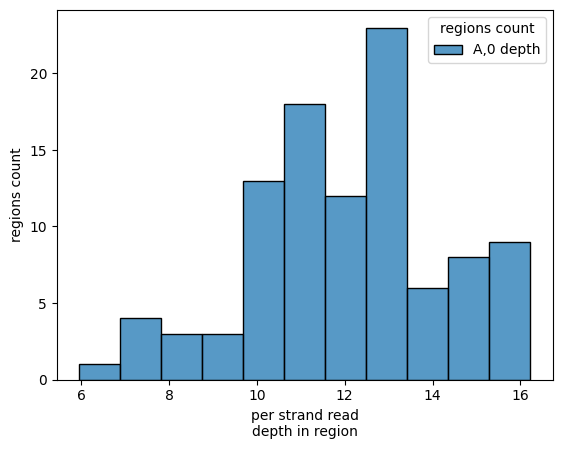

In [ ]:
plot_depth_histogram.by_modification(
    mod_file_name=pileup_file,
    regions=ctcf_target_regions,
    window_size=1000,
    motifs=['A,0'],#,'CG,0'],
    one_depth_per_region=True,
)

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

<Axes: xlabel='per strand read\ndepth per position', ylabel='positions count'>

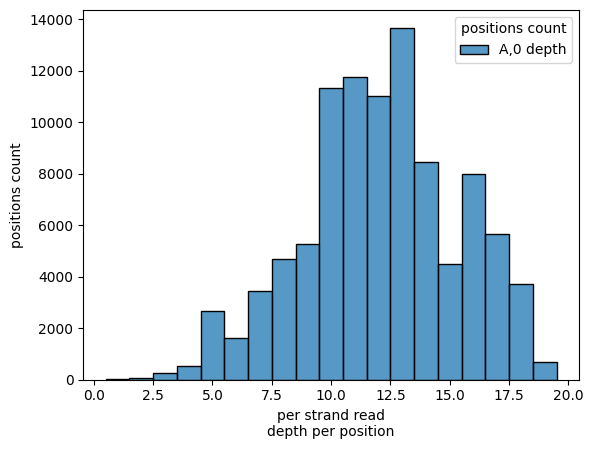

In [ ]:
plot_depth_histogram.by_modification(
    mod_file_name=pileup_file,
    regions=ctcf_target_regions,
    window_size=1000,
    motifs=['A,0'],#,'CG,0'],
    one_depth_per_region=False,
)

# Advanced Use Cases

## Clustering and Classification

This section shows how to work with processed files (`pileup.sorted.bed.gz` and `extract.h5`) to discover structure in your data.

- **Read clustering**: build fixed-length windows per read, compute features (PCA, autocorrelation, density, stats), and cluster molecules. Supports single motifs or combined multi-motif windows.
- **Read classification**: train a binary classifier on read features to quantify separability between two samples; includes train/test metrics, confusion matrices, and per-read profile plots.
- **Region clustering**: cluster loci on their pileup profiles (single motif or concatenated multi-motif features), and visualize mean profiles plus genome distribution.
- **Region classification**: treat each locus feature vector as a sample for downstream classifiers.

Optional clustering deps: `scikit-learn`, `scipy`, `hdbscan`, `umap-learn`, `pyranges`, `xgboost` (install via `pip install dimelo[clustering]`).
Make sure earlier parsing steps have produced the processed files before running these examples.

### Read analysis tips
- Use `span_full_window=True` and `orientation_aware=True` when extracting to keep windows consistent.
- For multi-motif windows, set `require_all_motifs=True` to drop reads missing motifs instead of zero-filling.
- Drop low-information reads by setting `require_nonzero_valid=True` and `min_valid_fraction` in `read_window_feature_matrix`.
- Inspect cluster/classifier QC: profile plots for clusters, confusion matrices and per-read profile plots for classifiers.
- Check locus homogeneity with `summarize_read_clusters_by_region` (dominant_fraction/entropy) to see if clusters are locus-driven.
- Beware class imbalance in classifiers; look at both accuracy and ROC-AUC, and at confusion matrices to spot overfitting.

### Read Clustering

#### Single motif (merged on-target vs off-target reads)

This example uses the notebook test data directly: extract read windows separately from `ctcf_target_regions`
and `ctcf_off_target_regions`, merge them, and run unsupervised clustering to see whether clusters enrich for one group.


*Motif semantics*: extract output stores one row per motif per read. For multi-motif analyses, use
`build_multimotif_read_windows` and either:
- `motif_profile_mode="single_axis"` to overlay motif profiles on a shared y-axis, or
- `motif_profile_mode="separate_axes"` to keep each motif on its own y-scale.


**Sampling for speed**: Use `cluster.sample_rows` to downsample reads or loci before clustering/classification. Example:

```python
sampled_feat, sampled_labels, idx = cluster.sample_rows(feature_matrix, labels, frac=0.2, stratify=True)
```

Run heavy algorithms (e.g., spectral/DBSCAN/UMAP) on the sample, then apply insights back to the full set.

Reads used: on_target=2173, off_target=4030, total=6203
Cluster purity vs on/off labels: 0.802
Counts by cluster and region set:
region_set  off_target  on_target
cluster                          
0                 3939       1140
1                   91       1033
Within-cluster fractions:
region_set  off_target  on_target
cluster                          
0                0.776      0.224
1                0.081      0.919


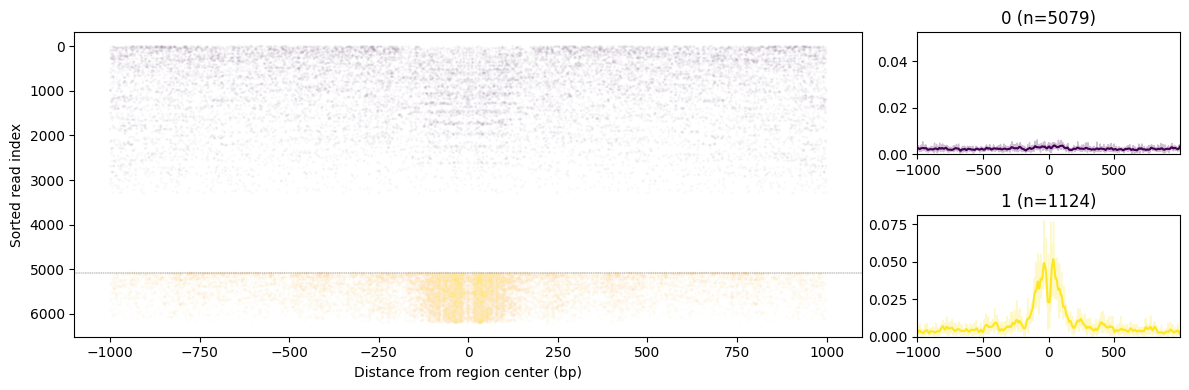

In [ ]:
from dimelo import cluster
import numpy as np
import pandas as pd
import inspect
from bisect import bisect_left, bisect_right

# Backend-safe path: infer one shared window size and enforce it for both extractions
# Fixed shared window_size for tutorial reproducibility.
shared_window = 1000
region_window_size = 1000
region_label_mode = "overlap_any"  # "center" | "overlap_any"

# Exposed plotting handles for tuning
plot_point_size = 1.2
plot_point_alpha = 0.015
profile_smoothing = "gaussian"   # None | "gaussian" | "boxcar"
show_unsmoothed_overlay = True

# Compatibility helpers for mixed dimelo versions

def _supports_kwarg(callable_obj, name):
    try:
        return name in inspect.signature(callable_obj).parameters
    except Exception:
        return False


def _filter_supported_kwargs(callable_obj, kwargs):
    try:
        sig = inspect.signature(callable_obj).parameters
    except Exception:
        return kwargs
    return {k: v for k, v in kwargs.items() if k in sig}


def _cluster_window_kwargs(callable_obj, window_size):
    if _supports_kwarg(callable_obj, "window_size"):
        return {"window_size": window_size}
    return {"window_size": window_size}


def _region_plot_window_kwargs(window_size):
    if _supports_kwarg(cluster.plot_region_cluster_profiles, "window_size"):
        return {"window_size": window_size}
    if _supports_kwarg(cluster.plot_region_cluster_profiles, "window_size"):
        return {"window_size": window_size}
    return {}


def _read_window_config(window_size, orientation_aware=True):
    if _supports_kwarg(cluster.ReadWindowExtractionConfig, "window_size"):
        return cluster.ReadWindowExtractionConfig(
            window_size=window_size,
            orientation_aware=orientation_aware,
        )
    return cluster.ReadWindowExtractionConfig(
        window_size=window_size,
        orientation_aware=orientation_aware,
    )


def _merge_read_windows(results, source_labels):
    if hasattr(cluster, "merge_read_window_results"):
        return cluster.merge_read_window_results(
            results,
            source_labels=source_labels,
            align="error",
        )

    # Backward-compatible fallback for older dimelo versions
    widths = {r.data_matrix.shape[1] for r in results}
    if len(widths) != 1:
        raise ValueError(
            f"Read-window widths do not match: {sorted(widths)}. "
            "Use one shared extraction window for all groups."
        )

    data = np.vstack([r.data_matrix for r in results])
    all_have_val = all(r.val_matrix is not None for r in results)
    val = np.vstack([r.val_matrix for r in results]) if all_have_val else None
    metadata = []
    for label, result in zip(source_labels, results):
        metadata.extend([dict(m, source_label=label) for m in result.metadata])

    return cluster.ReadWindowExtractionResult(
        data_matrix=data,
        val_matrix=val,
        metadata=metadata,
        datasets=list(results[0].datasets),
        regions_dict=None,
    )


def _plot_cluster_profiles_compat(**kwargs):
    fn = cluster.plot_cluster_profiles
    safe_kwargs = _filter_supported_kwargs(fn, kwargs)
    return fn(**safe_kwargs)


def _plot_region_cluster_profiles_compat(**kwargs):
    fn = cluster.plot_region_cluster_profiles
    safe_kwargs = _filter_supported_kwargs(fn, kwargs)
    return fn(**safe_kwargs)


def _plot_classification_profiles_compat(data_matrix, predictions, **kwargs):
    if not hasattr(cluster, "plot_classification_profiles"):
        print("plot_classification_profiles not available in this dimelo version; skipping profile view.")
        return None

    fn = cluster.plot_classification_profiles
    call_kwargs = dict(kwargs)
    call_kwargs.update({"data_matrix": np.asarray(data_matrix), "predictions": predictions})
    call_kwargs = _filter_supported_kwargs(fn, call_kwargs)
    return fn(**call_kwargs)


def _confusion_labels(predictions, split="test", positive_label=None):
    df = predictions[predictions["split"] == split].reset_index(drop=True)
    classes = sorted(pd.unique(df["true_label"]))
    if len(classes) != 2:
        raise ValueError("Confusion grouping requires exactly two classes.")
    positive = positive_label if positive_label is not None else classes[-1]
    true_vals = df["true_label"].to_numpy()
    pred_vals = df["pred_label"].to_numpy()
    labels = np.empty(len(df), dtype=object)
    labels[(true_vals != positive) & (pred_vals != positive)] = "TN"
    labels[(true_vals != positive) & (pred_vals == positive)] = "FP"
    labels[(true_vals == positive) & (pred_vals != positive)] = "FN"
    labels[(true_vals == positive) & (pred_vals == positive)] = "TP"
    idx = df["row_index"].astype(int).to_numpy() if "row_index" in df.columns else None
    return labels, idx


def _plot_region_classification_profiles_compat(pileup_matrix, predictions, **kwargs):
    if hasattr(cluster, "plot_region_classification_profiles"):
        fn = cluster.plot_region_classification_profiles
        call_kwargs = dict(kwargs)
        call_kwargs.update({"pileup_matrix": pileup_matrix, "predictions": predictions})
        call_kwargs = _filter_supported_kwargs(fn, call_kwargs)
        try:
            return fn(**call_kwargs)
        except Exception as exc:
            print(f"Falling back from plot_region_classification_profiles due to: {exc}")

    # Backward-compatible fallback: derive confusion labels and call region cluster plot
    split = kwargs.get("split", "test")
    group_by = kwargs.get("group_by", "pred_label")
    matrix = np.asarray(pileup_matrix)

    df = predictions[predictions["split"] == split].reset_index(drop=True)
    if group_by == "confusion":
        labels, idx = _confusion_labels(predictions, split=split, positive_label=kwargs.get("positive_label"))
    else:
        labels = df[group_by].to_numpy()
        idx = df["row_index"].astype(int).to_numpy() if "row_index" in df.columns else None

    if idx is not None:
        matrix = matrix[idx]

    window_kwargs = _region_plot_window_kwargs(kwargs.get("window_size", None))

    return _plot_region_cluster_profiles_compat(
        pileup_matrix=matrix,
        labels=labels,
        **window_kwargs,
        motif_index=kwargs.get("motif_index", 0),
        motif_count=kwargs.get("motif_count", None),
        plot_all_motifs=kwargs.get("plot_all_motifs", False),
        motif_labels=kwargs.get("motif_labels", None),
        motif_colors=kwargs.get("motif_colors", None),
        motif_profile_mode=kwargs.get("motif_profile_mode", "single_axis"),
        color_points_by=kwargs.get("color_points_by", "cluster"),
        point_size=kwargs.get("point_size", 1.0),
        point_alpha=kwargs.get("point_alpha", 0.01),
        smoothing=kwargs.get("smoothing", None),
        smooth_win=kwargs.get("smooth_win", 21),
        smooth_sigma=kwargs.get("smooth_sigma", 6.0),
        show_unsmoothed_overlay=kwargs.get("show_unsmoothed_overlay", False),
    )


def _load_intervals_by_chrom(path):
    intervals = {}
    with open(path) as handle:
        for line in handle:
            if not line.strip() or line.startswith("#"):
                continue
            fields = line.strip().split()[:3]
            if len(fields) < 3:
                continue
            chrom, start, end = fields[0], int(fields[1]), int(fields[2])
            intervals.setdefault(chrom, []).append((start, end))
    for chrom in intervals:
        intervals[chrom].sort()
    return intervals


def _contains_point(intervals, point):
    i = bisect_right(intervals, (point, float("inf"))) - 1
    return i >= 0 and intervals[i][0] <= point < intervals[i][1]


def _overlap_bp(start_a, end_a, start_b, end_b):
    return max(0, min(end_a, end_b) - max(start_a, start_b))


def _has_overlap(intervals, start, end, min_overlap_bp=1):
    if not intervals:
        return False
    i = max(0, bisect_left(intervals, (start, -1)) - 1)
    while i < len(intervals):
        s, e = intervals[i]
        if s >= end:
            break
        if _overlap_bp(start, end, s, e) >= min_overlap_bp:
            return True
        i += 1
    return False


def _label_regions_from_targets(region_info, on_bed, off_bed, mode="overlap_any", min_overlap_bp=1):
    on_intervals = _load_intervals_by_chrom(on_bed)
    off_intervals = _load_intervals_by_chrom(off_bed)
    labels = []
    for chrom, start, end, _ in region_info:
        start_i, end_i = int(start), int(end)
        if mode == "center":
            center = (start_i + end_i) // 2
            in_on = _contains_point(on_intervals.get(chrom, []), center)
            in_off = _contains_point(off_intervals.get(chrom, []), center)
        elif mode == "overlap_any":
            in_on = _has_overlap(on_intervals.get(chrom, []), start_i, end_i, min_overlap_bp=min_overlap_bp)
            in_off = _has_overlap(off_intervals.get(chrom, []), start_i, end_i, min_overlap_bp=min_overlap_bp)
        else:
            raise ValueError("mode must be 'center' or 'overlap_any'.")

        if in_on and not in_off:
            labels.append("on_target")
        elif in_off and not in_on:
            labels.append("off_target")
        elif in_on and in_off:
            labels.append("on_target")
        else:
            labels.append("unlabeled")
    return np.array(labels, dtype=object)


rw_on = cluster.extract_read_windows(
    hdf5_file=extract_file,
    motifs=["A,0"],
    regions=ctcf_target_regions,
    config=_read_window_config(shared_window, orientation_aware=True),
    span_full_window=False,
)

rw_off = cluster.extract_read_windows(
    hdf5_file=extract_file,
    motifs=["A,0"],
    regions=ctcf_off_target_regions,
    config=_read_window_config(shared_window, orientation_aware=True),
    span_full_window=False,
)

rw_single = _merge_read_windows(
    [rw_on, rw_off],
    source_labels=["on_target", "off_target"],
)

feat_single, _ = cluster.read_window_feature_matrix(
    rw_single,
    n_pca=6,
    use_peak_features=False,
)
clust_single = cluster.cluster_read_windows(
    feat_single,
    method="kmeans",
    n_clusters=2,
    random_state=42,
)

_plot_cluster_profiles_compat(
    data_matrix=rw_single.data_matrix,
    labels=clust_single.labels_size_ordered,
    val_matrix=rw_single.val_matrix,
    metadata=rw_single.metadata,
    **_cluster_window_kwargs(cluster.plot_cluster_profiles, shared_window),
    point_size=plot_point_size,
    point_alpha=plot_point_alpha,
    smoothing=profile_smoothing,
    show_unsmoothed_overlay=show_unsmoothed_overlay,
)

sample_labels_single = np.array([m.get("source_label", "unknown") for m in rw_single.metadata])
cluster_vs_group = pd.crosstab(
    clust_single.labels_size_ordered,
    sample_labels_single,
    rownames=["cluster"],
    colnames=["region_set"],
)
cluster_vs_group_frac = cluster_vs_group.div(cluster_vs_group.sum(axis=1), axis=0)
purity = cluster_vs_group.max(axis=1).sum() / cluster_vs_group.values.sum()

print(f"Reads used: on_target={rw_on.data_matrix.shape[0]}, off_target={rw_off.data_matrix.shape[0]}, total={rw_single.data_matrix.shape[0]}")
print(f"Cluster purity vs on/off labels: {purity:.3f}")
print("Counts by cluster and region set:")
print(cluster_vs_group)
print("Within-cluster fractions:")
print(cluster_vs_group_frac.round(3))




#### Multiple motif (merged on-target vs off-target reads)

This example plots both motifs with motif-matched colors. You can switch between:
- `motif_profile_mode="single_axis"` (shared y-axis) and
- `motif_profile_mode="separate_axes"` (one y-axis per motif).


/Users/ngamarra/Documents/GitHub/dimelo-toolkit/dimelo/cluster.py:1592: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax_left.scatter(


Multi-motif reads used: on_target=2173, off_target=4030, total=6203
Multi-motif cluster purity vs on/off labels: 0.807
col_0  off_target  on_target
row_0                       
0            3942       1112
1              88       1061


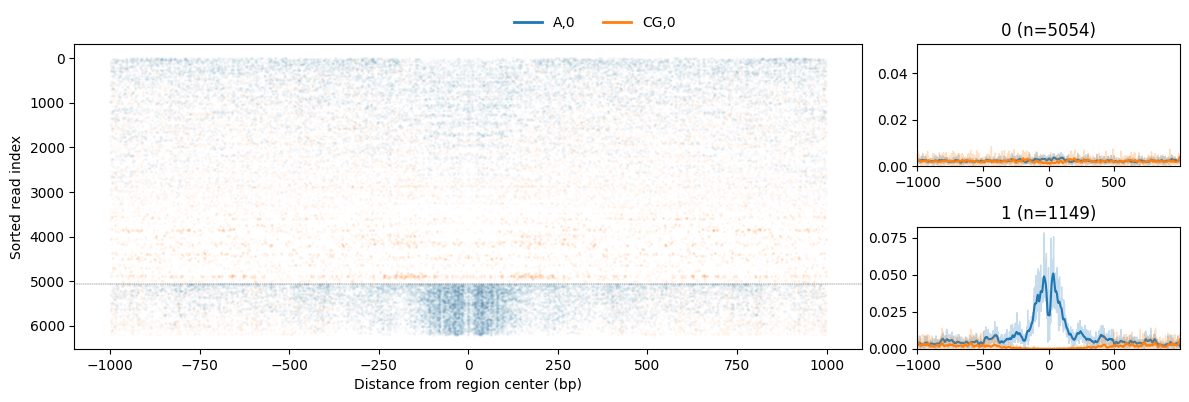

In [ ]:
from dimelo import cluster
import numpy as np
import pandas as pd

# Reuse shared_window from cell 75 when available
if "shared_window" not in globals():
    shared_window = 1000

rw_on_multi = cluster.build_multimotif_read_windows(
    hdf5_file=extract_file,
    motifs=["A,0", "CG,0"],
    regions=ctcf_target_regions,
    **_cluster_window_kwargs(cluster.build_multimotif_read_windows, shared_window),
    orientation_aware=True,
    span_full_window=False,
    require_all_motifs=True,
)

rw_off_multi = cluster.build_multimotif_read_windows(
    hdf5_file=extract_file,
    motifs=["A,0", "CG,0"],
    regions=ctcf_off_target_regions,
    **_cluster_window_kwargs(cluster.build_multimotif_read_windows, shared_window),
    orientation_aware=True,
    span_full_window=False,
    require_all_motifs=True,
)

rw_multi = _merge_read_windows(
    [rw_on_multi, rw_off_multi],
    source_labels=["on_target", "off_target"],
)

feat_multi, _ = cluster.read_window_feature_matrix(
    rw_multi,
    n_pca=6,
    use_peak_features=False,
)
clust_multi = cluster.cluster_read_windows(
    feat_multi,
    method="kmeans",
    n_clusters=2,
    random_state=42,
)

_plot_cluster_profiles_compat(
    data_matrix=rw_multi.data_matrix,
    labels=clust_multi.labels_size_ordered,
    val_matrix=rw_multi.val_matrix,
    metadata=rw_multi.metadata,
    **_cluster_window_kwargs(cluster.plot_cluster_profiles, shared_window),
    motif_count=2,
    motif_labels=["A,0", "CG,0"],
    plot_all_motifs=True,
    color_points_by="motif",
    motif_profile_mode="single_axis",  # switch to "separate_axes" if desired
    point_size=plot_point_size,
    point_alpha=plot_point_alpha,
    smoothing=profile_smoothing,
    show_unsmoothed_overlay=show_unsmoothed_overlay,
)

sample_labels_multi = np.array([m.get("source_label", "unknown") for m in rw_multi.metadata])
table_multi = pd.crosstab(clust_multi.labels_size_ordered, sample_labels_multi)
purity_multi = table_multi.max(axis=1).sum() / table_multi.values.sum()

print(f"Multi-motif reads used: on_target={rw_on_multi.data_matrix.shape[0]}, off_target={rw_off_multi.data_matrix.shape[0]}, total={rw_multi.data_matrix.shape[0]}")
print(f"Multi-motif cluster purity vs on/off labels: {purity_multi:.3f}")
print(table_multi)


### Read Classification

#### Single Motif

{'test': {'accuracy': 0.8356164383561644, 'roc_auc': 0.8820826559425002, 'confusion_matrix': [[707, 99], [105, 330]]}, 'train': {'accuracy': 0.8369609028617493, 'roc_auc': 0.8732761088441978, 'confusion_matrix': [[2875, 349], [460, 1278]]}}


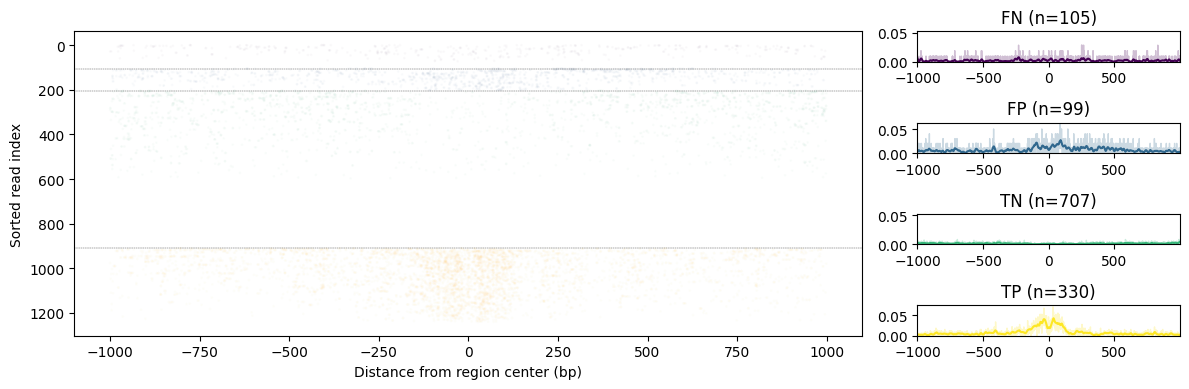

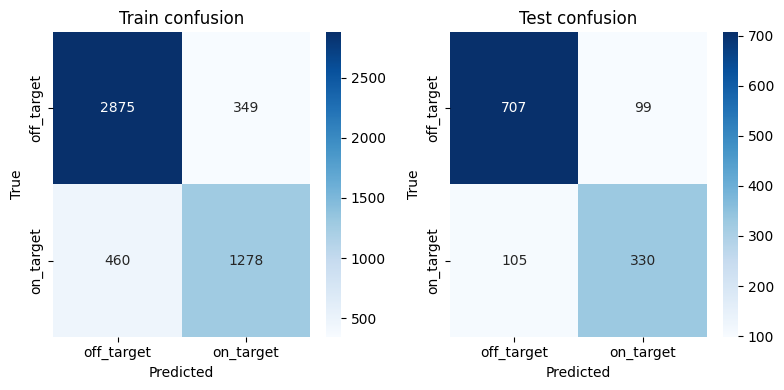

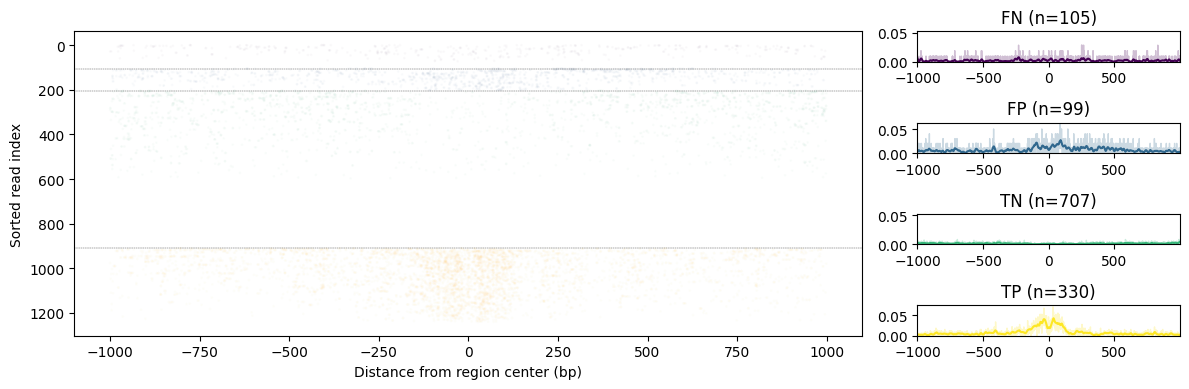

In [ ]:
#import numpy as np

# Use true on/off labels from the merged clustering example above
sample_labels_single = np.array([m.get("source_label", "unknown") for m in rw_single.metadata])

clf_single = cluster.classify_read_features_binary(
    feat_single,
    sample_labels=sample_labels_single,
    classifier="logreg",
    random_state=42,
)
print(clf_single["metrics"])
cluster.plot_confusion_matrices(clf_single["predictions"])

_plot_classification_profiles_compat(
    rw_single.data_matrix,
    clf_single["predictions"],
    val_matrix=rw_single.val_matrix,
    metadata=rw_single.metadata,
    split="test",
    group_by="confusion",
    **_cluster_window_kwargs(cluster.plot_classification_profiles, shared_window),
    point_size=plot_point_size,
    point_alpha=plot_point_alpha,
    smoothing=profile_smoothing,
    show_unsmoothed_overlay=show_unsmoothed_overlay,
)


*Tip*: For concatenated motif windows, use `motif_index` in plotting helpers to choose which motif slice to visualize (e.g., 0 for the first motif, 1 for the second).

#### Multiple motifs

{'test': {'accuracy': 0.8356164383561644, 'roc_auc': 0.9029776674937966, 'confusion_matrix': [[705, 101], [103, 332]]}, 'train': {'accuracy': 0.8405884723901652, 'roc_auc': 0.9012457275268627, 'confusion_matrix': [[2865, 359], [432, 1306]]}}


/Users/ngamarra/Documents/GitHub/dimelo-toolkit/dimelo/cluster.py:1592: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax_left.scatter(


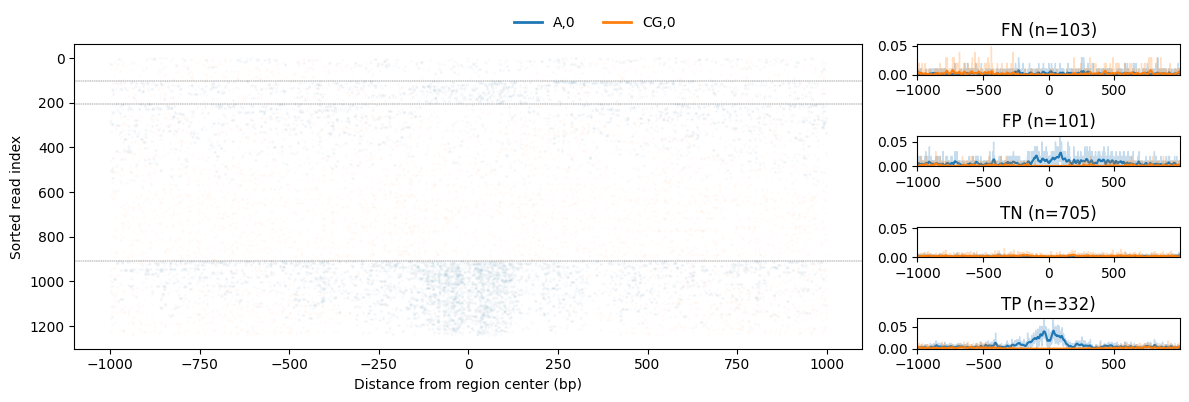

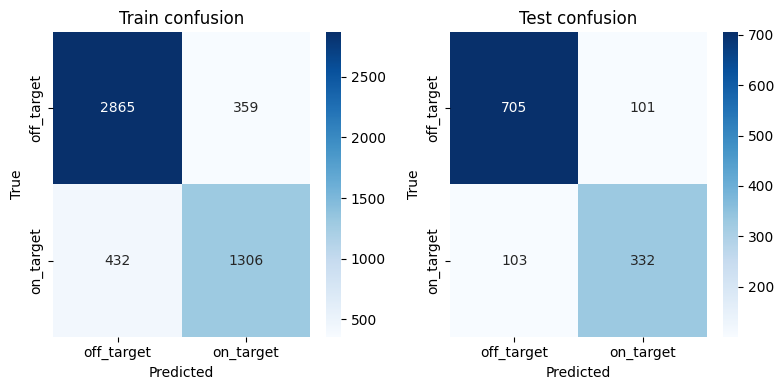

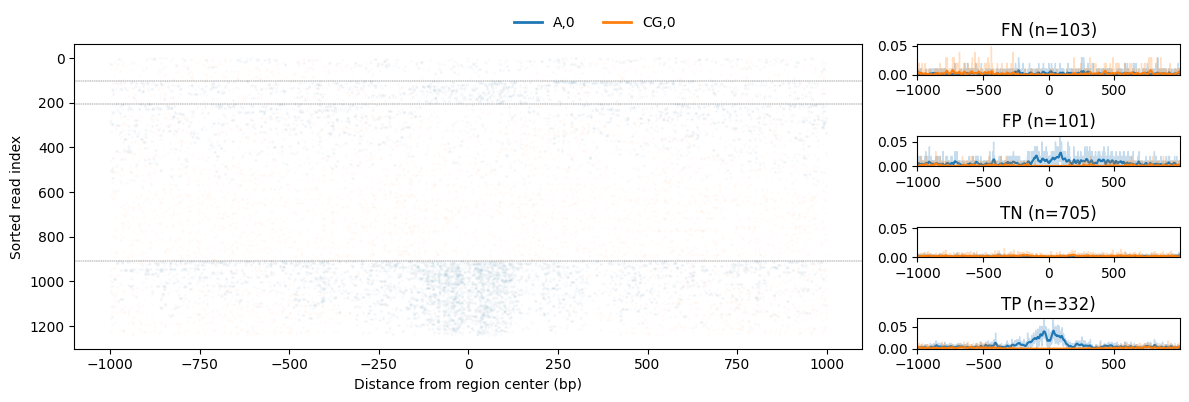

In [ ]:
import numpy as np

sample_labels_multi = np.array([m.get("source_label", "unknown") for m in rw_multi.metadata])

clf_multi = cluster.classify_read_features_binary(
    feat_multi,
    sample_labels=sample_labels_multi,
    classifier="logreg",
    random_state=42,
)
print(clf_multi["metrics"])
cluster.plot_confusion_matrices(clf_multi["predictions"])

_plot_classification_profiles_compat(
    rw_multi.data_matrix,
    clf_multi["predictions"],
    val_matrix=rw_multi.val_matrix,
    metadata=rw_multi.metadata,
    split="test",
    group_by="confusion",
    **_cluster_window_kwargs(cluster.plot_classification_profiles, shared_window),
    motif_count=2,
    motif_labels=["A,0", "CG,0"],
    plot_all_motifs=True,
    color_points_by="motif",
    motif_profile_mode="single_axis",
    point_size=plot_point_size,
    point_alpha=plot_point_alpha,
    smoothing=profile_smoothing,
    show_unsmoothed_overlay=show_unsmoothed_overlay,
)


### Read-Cluster to Region Association


Read-level clustering stays the primary inference step. Here we aggregate those cluster labels back onto regions, then plot the region-by-cluster association matrix. The plotting prep accepts the long-form association table directly, and it also normalizes the legacy wide summary output from `summarize_read_clusters_by_region`.


In [ ]:
from dimelo import plotting, plotting_matplotlib
import pandas as pd

region_sort_mode = "genomic"  # initial sort before source-label refinement
association_strength_aggregate = "max"  # used when region_sort_mode="association_strength"
top_regions_per_cluster = 8

association_summary_A = cluster.summarize_read_clusters_by_region(
    metadata=rw_multi.metadata,
    labels=clust_multi.labels_size_ordered,
    include_strand=True,
)
association_payload_A = plotting.prepare_read_cluster_region_association_data(
    association_summary_A,
    value_mode="fraction",
    top_n_regions_per_cluster=top_regions_per_cluster,
    region_sort=region_sort_mode,
    association_strength_aggregate=association_strength_aggregate,
)

axis_table = association_payload_A["region_axis_table"].copy()

# Primary source labeling from read metadata (most frequent source per region_id).
meta_df = pd.DataFrame(rw_multi.metadata).copy()
if not meta_df.empty and {"chromosome", "region_start", "region_end"}.issubset(meta_df.columns):
    if "region_strand" not in meta_df.columns:
        meta_df["region_strand"] = "."
    meta_df["region_id"] = meta_df.apply(
        lambda row: f"{row['chromosome']}:{int(row['region_start'])}-{int(row['region_end'])}:{row.get('region_strand', '.')}",
        axis=1,
    )
    if "source_label" not in meta_df.columns:
        meta_df["source_label"] = "unknown"
    source_by_region = (
        meta_df.groupby(["region_id", "source_label"], dropna=False)
        .size()
        .reset_index(name="n")
        .sort_values(["region_id", "n"], ascending=[True, False])
        .drop_duplicates(subset=["region_id"], keep="first")
        .loc[:, ["region_id", "source_label"]]
    )
    axis_table = axis_table.merge(source_by_region, on="region_id", how="left")

if "source_label" not in axis_table.columns:
    axis_table["source_label"] = "unknown"
axis_table["source_label"] = axis_table["source_label"].fillna("unknown")

# Optional fallback from region overlap for unresolved labels.
if (
    {"chrom", "start", "end"}.issubset(axis_table.columns)
    and "ctcf_target_regions" in globals()
    and "ctcf_off_target_regions" in globals()
    and "_label_regions_from_targets" in globals()
):
    unresolved = axis_table["source_label"].isin(["unknown", "unlabeled"])
    if unresolved.any():
        region_info = [
            (str(row.chrom), int(row.start), int(row.end), str(getattr(row, "strand", ".")))
            for row in axis_table.loc[unresolved].itertuples(index=False)
        ]
        inferred = _label_regions_from_targets(
            region_info,
            on_bed=ctcf_target_regions,
            off_bed=ctcf_off_target_regions,
            mode="overlap_any",
            min_overlap_bp=1,
        )
        axis_table.loc[unresolved, "source_label"] = inferred

source_priority = {"on_target": 0, "off_target": 1, "unlabeled": 2, "unknown": 3}
axis_table["_source_rank"] = (
    axis_table["source_label"].map(source_priority).fillna(99).astype(int)
)

# Final ordering for this tutorial: source bed first, then genomic coordinates.
axis_sorted = axis_table.sort_values(
    ["_source_rank", "chrom", "start", "end"],
    ascending=[True, True, True, True],
).drop(columns=["_source_rank"]).reset_index(drop=True)
region_order = axis_sorted["region_id"].tolist()

matrix_table = association_payload_A["matrix_table"].copy()
matrix_sorted = (
    matrix_table.set_index("region_id")
    .loc[region_order]
    .reset_index()
)

association_payload_A["region_axis_table"] = axis_sorted
association_payload_A["matrix_table"] = matrix_sorted
association_payload_A["metadata"] = {
    **association_payload_A.get("metadata", {}),
    "region_sort": "source_bed_then_genomic",
}

print("Association payload metadata")
display(pd.DataFrame([association_payload_A["metadata"]]))
print("Region axis preview (sorted)")
display(axis_sorted[["region_id", "chrom", "start", "end", "source_label"]].head())
print("Source label counts")
display(axis_sorted["source_label"].value_counts(dropna=False).rename("n_regions"))


#### Top regions per cluster


In [ ]:
association_payload_A["top_regions_table"].head(10)


,region_id,chrom,start,end,strand,cluster,count,fraction,total_reads,value,rank
0,chr12:57871837-57871987:-,chr12,57871837,57871987,-,0,24,1.000000,24,1.000000,1
1,chr12:57871885-57871987:-,chr12,57871885,57871987,-,0,24,1.000000,24,1.000000,2
2,chr12:57875753-57875855:-,chr12,57875753,57875855,-,0,25,1.000000,25,1.000000,3
3,chr12:57875753-57875903:-,chr12,57875753,57875903,-,0,25,1.000000,25,1.000000,4
4,chr14:17377273-17377423:+,chr14,17377273,17377423,+,0,23,1.000000,23,1.000000,5
5,chr9:145236510-145236828:+,chr9,145236510,145236828,+,1,19,0.904762,21,0.904762,1
6,chr9:145236511-145236827:-,chr9,145236511,145236827,-,1,19,0.904762,21,0.904762,2
7,chr20:33337048-33337366:-,chr20,33337048,33337366,-,1,17,0.894737,19,0.894737,3
8,chr2:44484677-44484995:+,chr2,44484677,44484995,+,1,19,0.863636,22,0.863636,4
9,chr20:33337049-33337365:+,chr20,33337049,33337365,+,1,16,0.842105,19,0.842105,5


#### Karyotype view of top associated regions

This adds a genome-level view under **Top regions per cluster**:
- each chromosome is vertical and proportional to true chromosome length,
- coordinate increases downward (0 near the top, chromosome length near the bottom),
- loci are colored by cluster assignment, and
- optional haplotype-aware backbone shading is enabled when maternal/paternal naming is detected.


In [ ]:
from pathlib import Path
import pandas as pd

from dimelo import cluster

karyotype_chromosome_order = "natural"  # "length_desc" | "length_asc" | "natural" | custom list
karyotype_min_visible_bp = 20_000
karyotype_detect_haplotype_shading = True

matrix_table = association_payload_A["matrix_table"].copy()
axis_table = association_payload_A["region_axis_table"].copy()
cluster_columns = [c for c in matrix_table.columns if c != "region_id"]

if matrix_table.empty or axis_table.empty or not cluster_columns:
    print("No region-association rows available for karyotype plot.")
else:
    dominant_cluster = matrix_table.loc[:, cluster_columns].astype(float).idxmax(axis=1).astype(str)
    dominant_by_region = pd.DataFrame({
        "region_id": matrix_table["region_id"].astype(str),
        "cluster": dominant_cluster,
    })

    karyo_table = axis_table.merge(dominant_by_region, on="region_id", how="inner")
    karyo_table["name"] = karyo_table["cluster"].astype(str)
    karyo_table["score"] = 0
    if "strand" not in karyo_table.columns:
        karyo_table["strand"] = "."
    karyo_table["strand"] = karyo_table["strand"].fillna(".")

    artifacts_dir = Path("artifacts/notebook")
    artifacts_dir.mkdir(parents=True, exist_ok=True)

    karyotype_bed = artifacts_dir / "association_regions_by_dominant_cluster.bed"
    karyo_table.loc[:, ["chrom", "start", "end", "name", "score", "strand"]].to_csv(
        karyotype_bed,
        sep="	",
        header=False,
        index=False,
    )

    chrom_sizes_path = None
    if "ref_genome_file" in globals():
        ref_path = Path(str(ref_genome_file))
        candidate = ref_path.with_suffix(ref_path.suffix + ".fai")
        if candidate.exists():
            chrom_sizes_path = candidate

    if chrom_sizes_path is None:
        inferred_sizes = (
            karyo_table.groupby("chrom", as_index=False)["end"]
            .max()
            .rename(columns={"chrom": "Chromosome", "end": "Length"})
        )
        inferred_sizes["Length"] = (inferred_sizes["Length"] * 1.05).astype(int)
        chrom_sizes_path = artifacts_dir / "inferred.chrom.sizes"
        inferred_sizes.to_csv(chrom_sizes_path, sep="	", header=False, index=False)

    fig = cluster.plot_cluster_karyotype(
        region_bed=karyotype_bed,
        chrom_sizes=chrom_sizes_path,
        chromosome_order=karyotype_chromosome_order,
        invert_position_axis=True,
        detect_haplotype_backbone_shading=karyotype_detect_haplotype_shading,
        min_visible_bp=karyotype_min_visible_bp,
    )

    print(f"Wrote karyotype BED to {karyotype_bed}")
    print(f"Using chromosome sizes from {chrom_sizes_path}")
    for chrom in ["chr9", "chr12", "chr20"]:
        n = int((karyo_table["chrom"].astype(str) == chrom).sum())
        print(f"{chrom}: {n} plotted region(s)")


#### Association heatmap


In [ ]:
import matplotlib.pyplot as plt

fig, ax = plotting_matplotlib.plot_read_cluster_region_association_heatmap_matplotlib(
    association_payload_A,
    title="Read-cluster association by region (sorted: source bed -> genomic)",
    region_label_mode="chromosome",
    max_region_labels=24,
    row_annotation_column="source_label",
    row_annotation_title="Source bed",
    row_annotation_palette={
        "on_target": "#D95F02",
        "off_target": "#1B9E77",
        "unlabeled": "#7570B3",
        "unknown": "#999999",
    },
    group_region_labels=True,
    group_label_columns=["source_label", "chrom"],
)
plt.show()


## Export

For some use cases, such as loading pileup information into a genome browser, it can be desireable to create files with less information content than the full bedmethyls. The `export` module contains functions to do these sorts of exports. 

In [ ]:
pileup_file = 'dimelo/test/output/ctcf_demo_pileup_on_target/pileup.sorted.bed.gz'
ref_genome_file = 'dimelo/test/output/chm13.draft_v1.0.fasta'
print(pileup_file)
print(ref_genome_file)

dimelo/test/output/ctcf_demo_pileup_on_target/pileup.sorted.bed.gz
dimelo/test/output/chm13.draft_v1.0.fasta


In [ ]:
from dimelo import export
export.pileup_to_bigwig(
    bedmethyl_file = pileup_file,
    motif = 'A,0', # the file will contain mod fraction for a specified motif
    bigwig_file = None, # if None, this will default to pileup.fractions.bigwig in the pileup_file directory
    strand = '.', # specifying + or - will save only mod fractions for the strand in question so you can see strand-specific features
    chunk_size = 1000, # mod positions per bigwig write operation. defaults to 1000. minor effect on performance for most reasonable values
)

Step 1: Indexing contigs in pileup.sorted.bed.gz to set up bigwig header for pileup.fractions.bigwig:   0%|   …

Indexing chr1.: 0it [00:00, ?it/s]

Indexing chr12.: 0it [00:00, ?it/s]

Indexing chr14.: 0it [00:00, ?it/s]

Indexing chr15.: 0it [00:00, ?it/s]

...

Writing chr6.:   0%|          | 0/17191 [00:00<?, ?it/s]

Writing chr7.:   0%|          | 0/3154 [00:00<?, ?it/s]

Writing chr8.:   0%|          | 0/2762 [00:00<?, ?it/s]

Writing chr9.:   0%|          | 0/3229 [00:00<?, ?it/s]

Writing chrX.:   0%|          | 0/6804 [00:00<?, ?it/s]

You can specify a ref genome when exporting to bigwig to speed up the setup for the bigwig header that defined contig lengths.

In [ ]:
export.pileup_to_bigwig(
    bedmethyl_file = pileup_file,
    motif = 'A,0', # the file will contain mod fraction for a specified motif
    bigwig_file = None, # if None, this will default to pileup.fractions.bigwig in the pileup_file directory'
    ref_genome = ref_genome_file, # if None, export will estimate contig lenghts from the bedmethyl file, which is slower
    strand = '.', # specifying + or - will save only mod fractions for the strand in question so you can see strand-specific features
    chunk_size = 1000, # mod positions per bigwig write operation. defaults to 1000. minor effect on performance for most reasonable values
)

Step 1: Indexing contigs in chm13.draft_v1.0.fasta to set up bigwig header for pileup.fractions.bigwig:   0%| …

Step 2: Writing pileup.sorted.bed.gz contents to pileup.fractions.bigwig:   0%|          | 0/17 [00:00<?, ?it/…

Writing chr1.: 0it [00:00, ?it/s]

Writing chr12.: 0it [00:00, ?it/s]

Writing chr14.: 0it [00:00, ?it/s]

...

Writing chr6.: 0it [00:00, ?it/s]

Writing chr7.: 0it [00:00, ?it/s]

Writing chr8.: 0it [00:00, ?it/s]

Writing chr9.: 0it [00:00, ?it/s]

Writing chrX.: 0it [00:00, ?it/s]

## Handling single read probabilities with plot_reads

You can still plot .h5 single read files with our `plot_reads` module, but because no threshold was applied in parsing a threshold must be provided to the plotting module.

In [ ]:
try:
    plot_reads.plot_reads(
        mod_file_name=extract_file_no_thresh, # the no threshold file
        regions=ctcf_target_regions, # same regions as before
        motifs=['A,0', 'CG,0'],
        window_size=1000,
    )
except Exception as e:
    print('This is expected to fail. Read the error message below:\n\n')
    print(e)

This is expected to fail. Read the error message below:


No threshold has been applied to this .h5 single read data. You must provide a threshold using the thresh parameter in order to extract binarized modification arrays.


Text(0, 0.5, 'reads')

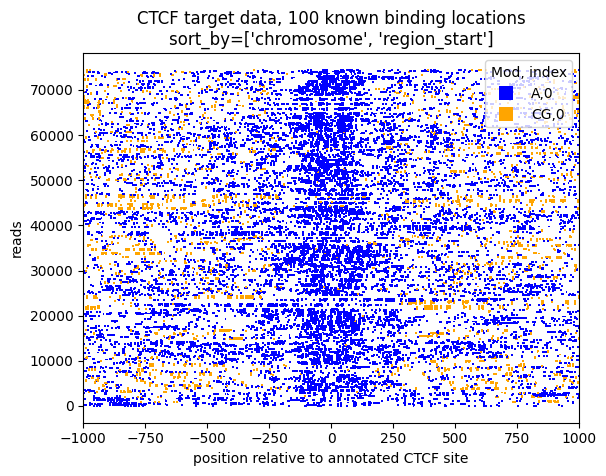

In [ ]:
sort_by = ['chromosome','region_start'] # you can sort reads also!
plot_reads.plot_reads(
    mod_file_name=extract_file_no_thresh,
    regions=ctcf_target_regions,
    motifs=['A,0', 'CG,0'],
    window_size=1000,
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    regions_5to3prime=True, # if set to True, regions on the reverse (-) strand will be flipped so everything is 5 prime to 3 prime
    thresh=190,
    sort_by=sort_by,
    s=2, 
)
plt.title(f'CTCF target data, 100 known binding locations\nsort_by={sort_by}')
plt.xlabel('position relative to annotated CTCF site')
plt.ylabel('reads')

## Manually Loading Processed Data

### Load sum total modified/valid base read counts by genomic regions

In [ ]:
from dimelo import load_processed

In [ ]:
modified_base_count,valid_base_count = load_processed.pileup_counts_from_bedmethyl(
    bedmethyl_file = pileup_file,
    motif = 'A,0',
    regions = ctcf_target_regions,
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
)
print('total methylated adenines across regions in bed file:',modified_base_count,'\ntotal adenine reads called as methylated or unmethylated across regions in bed file:',valid_base_count)

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

total methylated adenines across regions in bed file: 14242 
total adenine reads called as methylated or unmethylated across regions in bed file: 174078


In [ ]:
modified_base_count,valid_base_count = load_processed.pileup_counts_from_bedmethyl(
    bedmethyl_file = pileup_file,
    motif = 'A,0',
    regions = 'chr1:114358436-114358754',
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
)
print('total methylated adenines in single window:',modified_base_count,'\ntotal adenine reads called as methylated or unmethylated in single window:',valid_base_count)

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

total methylated adenines in single window: 213 
total adenine reads called as methylated or unmethylated in single window: 1619


### Load pileup vectors (modified and valid base read counts) aligned to target region(s)

In [ ]:
modified_base_counts,valid_base_counts = load_processed.pileup_vectors_from_bedmethyl(
    bedmethyl_file = pileup_file,
    motif = 'A,0',
    regions = ctcf_target_regions, # Regions from bed file
    window_size = 10, # Trim/extend regions to same size
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    regions_5to3prime=False, # if set to True, regions on the reverse (-) strand will be flipped so everything is 5 prime to 3 prime
)
print('methylated adenines by position near peak center:\n',modified_base_counts,'\nadenine reads by position, called as methylated or unmethylated:\n',valid_base_counts)

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

methylated adenines by position near peak center:
 [38 53 32  6  4 54  2 83 90  0 85 39 15 45 11 18 11 16 38 20] 
adenine reads by position, called as methylated or unmethylated:
 [588 679 297 210  70 534  58 445 839   0 891 431  80 486  51 303 286 514
 491 589]


In [ ]:
modified_base_counts,valid_base_counts = load_processed.pileup_vectors_from_bedmethyl(
    bedmethyl_file = pileup_file,
    motif = 'A,0',
    regions = 'chr1:114358585-114358605', # Region from string specifier
    window_size = None, # No adjustment applied to regions 
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    regions_5to3prime=False, # if set to True, regions on the reverse (-) strand will be flipped so everything is 5 prime to 3 prime
)
print('methylated adenines by position near peak center:\n',modified_base_counts,'\nadenine reads by position, called as methylated or unmethylated:\n',valid_base_counts)

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

methylated adenines by position near peak center:
 [1 0 3 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0] 
adenine reads by position, called as methylated or unmethylated:
 [14  0 14  0  0 13 14 14 13  0 13  0  0  0  0  0  0  0 13  0]


### Load modified/valid base information by individual reads

The current function to load reads returns somewhat counterintuitive data structures; this will likely be changed in future. If you want to convert to a more straightforward list of read data dicts, where each element in the list represents specific modification types (e.g. A,0) on a specific read from a specific region, code is provided below. An example is also shown for how one might filter reads using list and dict comprehension using this structure. 

In [ ]:
read_data_list, datasets, _ = load_processed.read_vectors_from_hdf5(
    file=extract_file, # binarized modification calls
    regions=ctcf_target_regions,
    motifs=['CG,0','A,0'],
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    sort_by = ['chromosome','read_start','read_name']
)
# Print out the data from the first read
for idx,dataset in enumerate(datasets):
    print(dataset)
    for read_data in read_data_list:
        print('\t'+str(read_data[idx]))
        break
# create a list of dicts for easy processing
list_of_dicts = [dict(zip(datasets,data)) for data in read_data_list]
# pull out a read by info about it, in this case the name and motif
# note that if your regions parameter for load_processed.read_vectors_from_hdf5 has multiple windows 
# and a read is present in more than one of them, that read will be returned more than once, which is
# necessary and correct for e.g. the plot_reads functionality
print([read for read in list_of_dicts 
       if read['read_name']=='b35229d7-6592-48fa-ab21-53154531c984' 
       and read['motif']=='CG,0']
       )

chromosome
	chr1
mod_vector
	[False False False ... False False False]
motif
	A,0
read_end
	9206582
read_name
	bc8057e5-935b-4a1a-a0de-f7a4c0dbe4bb
read_start
	9127032
strand
	-
val_vector
	[False False False ... False False False]
region_start
	9169918
region_end
	9170236
region_strand
	+
read_length
	79550
CG,0_mod_fraction
	0.13551401869158877
A,0_mod_fraction
	0.017008797653958945
[{'chromosome': 'chr14', 'mod_vector': array([False, False, False, ..., False, False, False], shape=(239917,)), 'motif': 'CG,0', 'read_end': np.int32(44230138), 'read_name': 'b35229d7-6592-48fa-ab21-53154531c984', 'read_start': np.int32(43990221), 'strand': '-', 'val_vector': array([False, False, False, ..., False, False, False], shape=(239917,)), 'region_start': 44125008, 'region_end': 44125326, 'region_strand': '+', 'read_length': np.int32(239917), 'CG,0_mod_fraction': np.float64(0.08125), 'A,0_mod_fraction': np.float64(0.0076164874551971325)}, {'chromosome': 'chr14', 'mod_vector': array([False, False, 

In [ ]:
read_data_list, datasets, _ = load_processed.read_vectors_from_hdf5(
    file=extract_file_no_thresh, # raw modification probabilities
    regions='chr14:44125008-44125326',
    motifs=['CG,0','A,0'],
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
)
# Print out the data from the first read
for idx,dataset in enumerate(datasets):
    print(dataset)
    for read_data in read_data_list:
        print('\t',read_data[idx])
        break
# create a list of dicts for easy processing
list_of_dicts = [dict(zip(datasets,data)) for data in read_data_list]
# pull out a read by info about it, in this case the name and motif
# note that if your regions parameter for load_processed.read_vectors_from_hdf5 has multiple windows 
# and a read is present in more than one of them, that read will be returned more than once, which is
# necessary and correct for e.g. the plot_reads functionality
print([read for read in list_of_dicts 
       if read['read_name']=='b35229d7-6592-48fa-ab21-53154531c984' 
       and read['motif']=='CG,0']
       )

chromosome
	 chr14
mod_vector
	 [0. 0. 0. ... 0. 0. 0.]
motif
	 A,0
read_end
	 44230138
read_name
	 b35229d7-6592-48fa-ab21-53154531c984
read_start
	 43990221
strand
	 -
val_vector
	 [0 0 0 ... 0 0 0]
region_start
	 44125008
region_end
	 44125326
region_strand
	 .
read_length
	 239917
CG,0_mod_fraction
	 0.09485774253731344
A,0_mod_fraction
	 0.020627618192698982
[{'chromosome': 'chr14', 'mod_vector': array([0., 0., 0., ..., 0., 0., 0.], shape=(239917,), dtype=float16), 'motif': 'CG,0', 'read_end': np.int32(44230138), 'read_name': 'b35229d7-6592-48fa-ab21-53154531c984', 'read_start': np.int32(43990221), 'strand': '-', 'val_vector': array([0, 0, 0, ..., 0, 0, 0], shape=(239917,)), 'region_start': 44125008, 'region_end': 44125326, 'region_strand': '.', 'read_length': np.int32(239917), 'CG,0_mod_fraction': np.float64(0.09485774253731344), 'A,0_mod_fraction': np.float64(0.020627618192698982)}]


### Load regions to a list

You can run any load_processed loader function one-by-one through a set of regions, rather than aggregating to a single output. This is implemented by the `load_processed.regions_to_list`, which takes a function handle to e.g. `load_processed.pileup_counts_from_bedmethyl` and runs it with the specified parameters but running each region in the regions specifier separately.

In [ ]:
from pathlib import Path
pileup_file = 'dimelo/test/output/ctcf_demo_pileup_on_target/pileup.sorted.bed.gz'
# Base input and output directories
test_data_dir = Path('./dimelo/test/data')
output_dir = Path('./dimelo/test/output')

output_dir.mkdir(exist_ok=True)

# Input files
ctcf_bam_file = test_data_dir / 'ctcf_demo.sorted.bam'
ctcf_guppy_bam_file = test_data_dir / 'winnowmap_guppy_merge_subset.updated.bam'
ctcf_target_regions = test_data_dir / 'ctcf_demo_peak.bed'
ctcf_off_target_regions = test_data_dir / 'ctcf_demo_not_peak.bed'
from dimelo import load_processed
print(load_processed.regions_to_list(
    function_handle = load_processed.pileup_counts_from_bedmethyl,
    regions=ctcf_target_regions,
    bedmethyl_file = pileup_file,
    motif = 'A,0',)
)

[(124, 1918), (124, 1892), (134, 1840), (75, 1806), (74, 1795), (85, 1281), (89, 1165), (89, 1165), (213, 1619), (213, 1593), (132, 1791), (143, 1870), (143, 1870), (72, 1487), (70, 1346), (70, 1319), (236, 2502), (114, 2184), (113, 2158), (105, 1621), (105, 1621), (108, 1648), (108, 1638), (254, 2031), (254, 2031), (249, 1993), (249, 1993), (63, 1147), (63, 1142), (49, 1116), (49, 1107), (135, 1905), (135, 1892), (128, 1734), (128, 1734), (80, 1939), (231, 2954), (231, 2920), (228, 2811), (249, 2811), (249, 2777), (157, 1788), (128, 2006), (128, 2006), (109, 1602), (109, 1582), (101, 1433), (101, 1413), (175, 2075), (175, 2061), (173, 2029), (158, 1712), (158, 1686), (167, 1623), (167, 1623), (176, 1345), (176, 1327), (179, 1520), (145, 2169), (144, 2152), (86, 1576), (86, 1576), (101, 1239), (101, 1050), (100, 1036), (194, 2409), (194, 2191), (125, 1373), (125, 1361), (118, 1330), (79, 1250), (79, 1237), (84, 1243), (121, 1264), (121, 1264), (218, 1496), (218, 1496), (254, 1496), (25

# Mod code specification and adjustment

In addition to the modification context motif and mod quality threshold, the `dimelo` package can delineate different modification codes. For example, a cytosine called with Dorado on Nanopore R10 traces can have modification scores reported for both `m` (methylation) and `h` (hydroxymethylation). These have different biological relevance and may be important to distinguish.

By default, the `dimelo` package only looks for methylation. However, the `motif` specifier can optionally include a third field, e.g. `CG,0,m` or `CG,0,h' to call out a specific mod code.

Different base callers may use different mod codes however. For example, Guppy and Megalodon for R9 Nanopore data tend to us `Y` for adenine and `Z` for cytosine, while the standard is `a` and `m`.

The `dimelo` package reports a warning if a specific mod code is not present, and the bundled `modkit` program offers a command line tool to make adjustments to bam files as desired.

In [ ]:
pileup_file_coded, pileup_regions = parse_bam.pileup(
    input_file=ctcf_bam_file_updated,
    output_name='ctcf_demo_pileup_on_target_mod_code_specified',
    ref_genome=ref_genome_file,
    output_directory=output_dir,
    regions=[ctcf_target_regions,ctcf_off_target_regions],
    # motifs=['A,0','CG,0'],
    # parsing can optionally specify mod codes. 
    # The default is Y or a for adenine and m or Z for cytosine, corresponding to methylation
    motifs = ['A,0,a','CG,0,m'], 
    thresh=190,
    window_size=1000,
    # cores = 1, # uncomment this line if your process appears to be terminating early (reduces memory usage)
    # quiet = True,
    # cleanup = False,
    # log=True,
    modkit_executable=MODKIT_BINARY,
)


`dimelo` lets you run even if the mod codes aren't found in the first 100 reads, but the warning is worth paying attention to: sometimes, as in this case, they actually aren't present at all!

In that case, plotting will yield an empty plot. We clearly need to properly specify the mod codes if we want the right result.

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

<Axes: xlabel='pos', ylabel='fraction modified bases'>

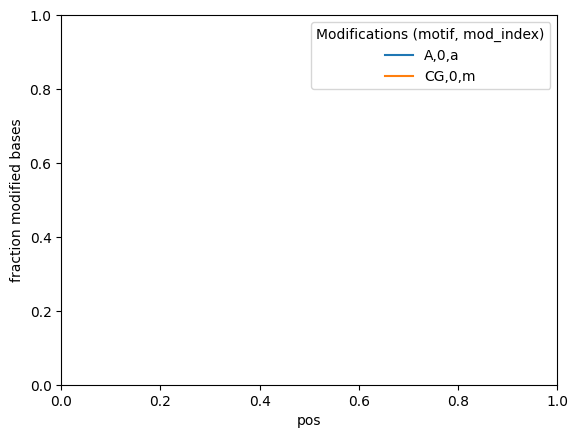

In [ ]:
from dimelo import plot_enrichment_profile
plot_enrichment_profile.by_modification(
    mod_file_name=pileup_file_coded,
    regions=ctcf_target_regions,
    window_size=1000,
    motifs=['A,0,a','CG,0,m'], # We know from above that these mod codes aren't present in our file!
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    regions_5to3prime=False, # if set to True, regions on the reverse (-) strand will be flipped so everything is 5 prime to 3 prime
    smooth_window=50,
)

The `modkit` command below will make the bam file work for the to-spec mod codes m and a. However, you must use this command with caution: `modkit` can and will adjust any mod code to any other mod code; you need to verify yourself that they are actually equivalent and thus that the operation is in fact valid.

In [ ]:
run_modkit_checked([
    "adjust-mods",
    "dimelo/test/output/ctcf_demo.updated.bam",
    "dimelo/test/output/ctcf_demo.recoded.bam",
    "--convert",
    "Y",
    "a",
    "--convert",
    "Z",
    "m",
])


In [ ]:
ctcf_bam_file_recoded = output_dir / 'ctcf_demo.recoded.bam'
pysam.index(str(ctcf_bam_file_recoded))

''

In [ ]:
pileup_file_recoded, pileup_regions = parse_bam.pileup(
    input_file=ctcf_bam_file_recoded,
    output_name='ctcf_demo_pileup_on_target_mod_code_specified_adjusted',
    ref_genome=ref_genome_file,
    output_directory=output_dir,
    regions=[ctcf_target_regions,ctcf_off_target_regions],
    # motifs=['A,0','CG,0'],
    # parsing can optionally specify mod codes. 
    # The default is Y or a for adenine and m or Z for cytosine, corresponding to methylation
    motifs = ['A,0,a','CG,0,m'], 
    thresh=190,
    window_size=1000,
    # cores = 1, # uncomment this line if your process appears to be terminating early (reduces memory usage)
    # quiet = True,
    # cleanup = False,
    # log=True,
    modkit_executable=MODKIT_BINARY,
)


Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

Loading data:   0%|          | 0/50 [00:00<?, ?it/s]

<Axes: xlabel='pos', ylabel='fraction modified bases'>

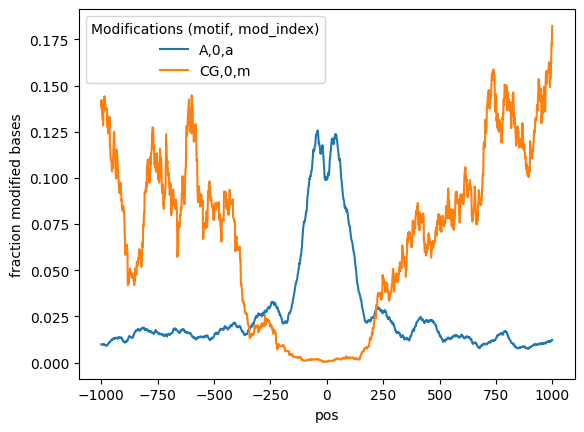

In [ ]:
from dimelo import plot_enrichment_profile
plot_enrichment_profile.by_modification(
    mod_file_name=pileup_file_recoded,
    regions=ctcf_target_regions,
    window_size=1000,
    motifs=['A,0,a','CG,0,m'],
    single_strand=False, # if set to True, regions that specify the strand will only pull from reads on the strand (as opposed to both strands)
    regions_5to3prime=False, # if set to True, regions on the reverse (-) strand will be flipped so everything is 5 prime to 3 prime
    smooth_window=50,
)

In [ ]:
# Two-window raster demo
# What it does:
# - selects window pairs from the same read,
# - keeps row sorting matched across motifs,
# - renders either scatter or heatmap panels.
#
# Flexible window specification options:
# 1) spacing-driven: n_windows + min_separation_bp
# 2) center-driven: window_center_offsets in primary-region coordinates

raster_render_mode = "scatter"  # "scatter" | "heatmap"
raster_x_axis_mode = "relative_to_primary"  # "relative_to_primary" | "centered"
raster_plot_all_motifs = True
raster_window_centers = [0, 2000]
raster_center_tolerance_bp = 800
show_heatmap_variant = True

try:
    fig, stats = cluster.plot_multisite_read_raster(
        read_windows=rw_multi,
        motif_index=0,
        motif_count=2,
        plot_all_motifs=raster_plot_all_motifs,
        motif_labels=["A,0", "CG,0"],
        window_center_offsets=raster_window_centers,
        center_tolerance_bp=raster_center_tolerance_bp,
        smoothing="gaussian",
        render_mode=raster_render_mode,
        x_axis_mode=raster_x_axis_mode,
        scatter_size=5.0,
        scatter_alpha=0.75,
    )
except ValueError as exc:
    print(f"Center-driven window selection failed ({exc}); using spacing-driven selection.")
    fig, stats = cluster.plot_multisite_read_raster(
        read_windows=rw_multi,
        motif_index=0,
        motif_count=2,
        plot_all_motifs=raster_plot_all_motifs,
        motif_labels=["A,0", "CG,0"],
        n_windows=2,
        min_separation_bp=1800,
        smoothing="gaussian",
        render_mode=raster_render_mode,
        x_axis_mode=raster_x_axis_mode,
        scatter_size=5.0,
        scatter_alpha=0.75,
    )
print("Two-window raster stats:", stats)

if show_heatmap_variant:
    fig_hm, stats_hm = cluster.plot_multisite_read_raster(
        read_windows=rw_multi,
        motif_index=0,
        motif_count=2,
        plot_all_motifs=raster_plot_all_motifs,
        motif_labels=["A,0", "CG,0"],
        n_windows=2,
        min_separation_bp=1800,
        smoothing="gaussian",
        render_mode="heatmap",
        x_axis_mode="centered",
    )
    print("Heatmap variant stats:", stats_hm)


### Three-site raster demo (`-2500`, `0`, `+2500`)

This example uses explicit centers (`window_center_offsets=[-2500, 0, 2500]`) to select three windows from the same read.


In [ ]:
try:
    fig3, stats3 = cluster.plot_multisite_read_raster(
        read_windows=rw_multi,
        motif_index=0,
        motif_count=2,
        plot_all_motifs=True,
        motif_labels=["A,0", "CG,0"],
        window_center_offsets=[-2000, 0, 2000],
        center_tolerance_bp=1000,
        render_mode="scatter",
        x_axis_mode="relative_to_primary",
        smoothing="gaussian",
        scatter_size=4.5,
        scatter_alpha=0.65,
    )
except ValueError as exc:
    print(f"Center-driven 3-window selection failed ({exc}); using spacing-driven selection.")
    fig3, stats3 = cluster.plot_multisite_read_raster(
        read_windows=rw_multi,
        motif_index=0,
        motif_count=2,
        plot_all_motifs=True,
        motif_labels=["A,0", "CG,0"],
        n_windows=3,
        min_separation_bp=1800,
        render_mode="scatter",
        x_axis_mode="relative_to_primary",
        smoothing="gaussian",
        scatter_size=4.5,
        scatter_alpha=0.65,
    )
print("Three-window raster stats:", stats3)
